In [24]:
# Instalamos solo lo que Colab no trae por defecto
!pip install datasets
!pip install evaluate
!pip install fsspec==2023.9.2
!pip install wordcloud
!pip install accelerate>=0.21.0



⚙️ **Requerimientos importantes sobre el ejercicio**

- El notebook debe ejecutarse **de principio a fin sin intervención manual**.
- Si utilizas librerías que no están incluidas por defecto en Google Colab, **asegúrate de instalarlas dentro del notebook** (por ejemplo: `!pip install ...`).

- Algunas celdas incluyen identificadores especiales que indican ciertas normas que **debes** respetar:
 - `#NO-MODIFY: DATA LOAD`  
    🔒 **No modifiques** el contenido de esta celda.

  - `#NO-MODIFY: VARIABLE NAME`  
    ✏️ Puedes modificar o añadir información **dentro de la celda**, pero **sin cambiar el nombre de la variable asignada**. No incluyas más variables de las existentes en la celda.

  - `#MODIFY: ADD INFO TO SOLVE FUNCTION`  
    🔧 Puedes modificar el **interior de la función** para resolver la tarea, pero **no cambies su nombre, la cabecera ni el `return`**.



## Imports

In [25]:
import numpy as np
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
# Add your imports here
# Solo importamos lo básico para el EDA aquí.
# Los imports de transformers y sklearn los hacemos más abajo,
# justo cuando los necesitemos.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
from collections import Counter
import re
import numpy as np
import torch


# 🔍 Ejercicio1: Detección de profesiones en tweets

## Enunciado

En este ejercicio vamos a trabajar con un conjunto de datos procedente de medios sociales online.

Utilizaremos un subconjunto de los datos de la tarea 1 del shared task [**ProfNER**](https://temu.bsc.es/smm4h-spanish), centrada en la detección de menciones a profesiones en tweets publicados durante la pandemia del COVID-19. El objetivo original de la tarea era analizar que profesiones podrían haber sido especialmente vulnerables en el contexto de la crisis sanitaria.

Para simplificar el ejercicio, he preparado una versión reducida del dataset original. Tu tarea será entrenar un clasificador binario basado en la arquitectura Transformers, que, dado un tweet, determine si contiene una mención explícita a una profesión (etiqueta `1`) o no (etiqueta `0`).




✅ **Objetivos del ejercicio**

A lo largo de este notebook, completarás las siguientes etapas para construir un clasificador de menciones a profesiones en tweets:

1. **Análisis Exploratorio de Datos (EDA)**: Calcular estadísticas básicas del conjunto de datos (como el número de ejemplos del training set, la distribución de clases del dataset, la longitud media de los textos) o crear visualizaciones para cmprender mejor el contenido de los documentos usando wordclouds o histogramas.

2. **Selección y justificación del modelo**: Elegir un modelo del Hub de Huggingface adecuado para los datos con los que se va a trabajar y el tipo de tarea a desarrollar.

3. **Entrenamiento del clasificador**: Entrenar el modelo de forma reproducible y evaluar su rendimiento sobreel conjunto de datos de validación, incluyendo un classification score y matriz de confusion

4. **Generación de predicciones sobre el conjunte de test**: Aplicar el modelo entrenado al conjunto de test, y guardar las predicciones en un archivo `.tsv` de 2 columnas `id` y `label` separadas por tabulador

📝 **Criterios de Evaluación**

Tu trabajo será evaluado según los siguientes criterios:

| Criterio                                            | Peso  |
|-----------------------------------------------------|--------|
| 🔍 Análisis exploratorio y preprocesamiento         | 20%   |
| 🤖 Selección y justificación del modelo             | 25%   |
| 📁 Formato y validez del archivo de predicciones    | 5%    |
| ⚙️ Ejecución correcta del notebook (sin intervención) | 10%   |
| 📈 Rendimiento del modelo sobre el conjunto de test | 30%   |
| ✍️ Claridad y calidad de las explicaciones          | 10%   |



🔔 **Nota importante:**

> El rendimiento del modelo se evaluará utilizando métricas estándar como el **F1-score** sobre el conjunto de test.

> El archivo de predicciones debe respetar **estrictamente** el formato solicitado (`id` y `label`, separados por tabulador y con extensión `.tsv`).  
  ❗ Si el archivo no cumple con este formato, **el ejercicio no podrá ser evaluado en esa sección**.

> El/la estudiante con el **mayor F1-score** obtendrá la puntuación máxima en el apartado de rendimiento. El resto de calificaciones se ajustarán de forma proporcional al mejor resultado



⚙️ **Requerimientos y reglas**

- El notebook debe ejecutarse **de principio a fin sin intervención manual**.
- Si utilizas librerías que no están incluidas por defecto en Google Colab, **asegúrate de instalarlas dentro del notebook** (por ejemplo: `!pip install ...`).

- Algunas celdas incluyen identificadores especiales que indican ciertas normas que **debes** respetar:
 - `#NO-MODIFY: DATA LOAD`  
    🔒 **No modifiques** el contenido de esta celda.

  - `#NO-MODIFY: VARIABLE NAME`  
    ✏️ Puedes modificar o añadir información **dentro de la celda**, pero **sin cambiar el nombre de la variable asignada**. No incluyas más variables de las existentes en la celda.

  - `#MODIFY: ADD INFO TO SOLVE FUNCTION`  
    🔧 Puedes modificar el **interior de la función** para resolver la tarea, pero **no cambies su nombre, la cabecera ni el `return`**.


# Tu resolución (rellena las celdas marcadas)

## Obtención de datos

Descargamos los datos del [repositorio de Huggingface](https://huggingface.co/datasets/luisgasco/profner_classification_master).

In [27]:
#NO-MODIFY: DATA LOAD
from datasets import load_dataset, Dataset, DatasetDict, ClassLabel
dataset = load_dataset("luisgasco/profner_classification_master")

El dataset contiene tres subsets:
- **train** y **validation**: Contienen el identificador del tweet, el texto, y su etiqueta, que podrá tener valor 1, si contiene una mención de una profesión; o valor 0, si no contiene una mención de una profesión.
- **test**: El test set tambiíen contiene la información de label por un requerimiento de Huggingface, pero el contenido de esta variable es siempre "-1". Es decir que deberéis predecir nuevas etiquetas una vez hayáis entrenado el modelo utilizando el train y el validation set.

## Análisis exploratorio de datos

Para hacer el análisis exploratorio de datos, transformamos cada subset a un pandas dataframe para mayor comodidad.

In [28]:
#NO-MODIFY: DATA LOAD
dataset_train_df = dataset["train"].to_pandas()
dataset_val_df = dataset["validation"].to_pandas()
dataset_test_df = dataset["test"].to_pandas()

**Número de documentos**

Obten con la función `get_num_docs_evaluation()` el número de documentos del dataset de training y validation.

> Recuerda incorporar la información para el cálculo dentro del a siguiente celda, sin modificar los atributos de entrada ni de salida de la función, ni su nombre.

In [29]:
#MODIFY: ADD INFO TO SOLVE FUNCTION
def get_num_docs_evaluation(dataset_df):
  # Contamos el número de filas = número de tweets
  num_docs = len(dataset_df)

  # No modifiques el return
  return num_docs


Una vez generada la función, puedes utilizarla posteriormente para calcular resultados y comentarlos

In [30]:
# Aplica la función
# Veamos cuántos tweets hay en cada parte del dataset
print(f"Documentos en train: {get_num_docs_evaluation(dataset_train_df)}")
print(f"Documentos en validation: {get_num_docs_evaluation(dataset_val_df)}")
print(f"Documentos en test: {get_num_docs_evaluation(dataset_test_df)}")


Documentos en train: 2786
Documentos en validation: 999
Documentos en test: 1001


**Número de documentos duplicados**

Obten con la función `detect_duplicates_evaluation()` el número de documentos duplicados del dataset de training y validation.

> Recuerda incorporar la información para el cálculo dentro del a siguiente celda, sin modificar los atributos de entrada ni de salida de la función, ni su nombre.

In [31]:
#MODIFY: ADD INFO TO SOLVE FUNCTION
def detect_duplicates_evaluation(dataset_df):
  # Buscamos textos repetidos
  num_duplicates = dataset_df.duplicated(subset=['text']).sum()

  # No modifiques el return
  return num_duplicates


Una vez generada la función, puedes utilizarla posteriormente para calcular resultados y comentarlos

In [32]:
# Aplica la función
# Verificamos si hay tweets repetidos
print(f"Duplicados en train: {detect_duplicates_evaluation(dataset_train_df)}")
print(f"Duplicados en validation: {detect_duplicates_evaluation(dataset_val_df)}")


Duplicados en train: 0
Duplicados en validation: 0


**Número de documentos por cada clase:**


Obten con la función `analyse_num_labels_evaluation()` para calcular el número de documentos de cada categoría en el dataset

> Recuerda incorporar la información para el cálculo dentro del a siguiente celda, sin modificar los atributos de entrada ni de salida de la función, ni su nombre.

In [33]:
#MODIFY: ADD INFO TO SOLVE FUNCTION
def analyse_num_labels_evaluation(dataset_df):
  # Contamos tweets con profesión (1) y sin profesión (0)
  num_positives = (dataset_df['label'] == 1).sum()
  num_negatives = (dataset_df['label'] == 0).sum()

  # No modifiques el return
  return num_positives, num_negatives


Una vez generada la función, puedes utilizarla posteriormente para calcular resultados y comentarlos

Train -> Con profesión: 1393, Sin profesión: 1393
Val   -> Con profesión: 238, Sin profesión: 761


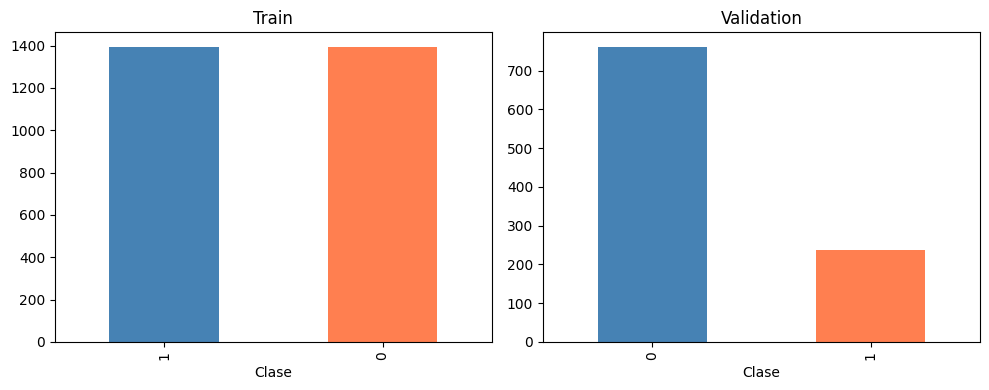

In [34]:
# Aplica la función
# Miramos si hay equilibrio entre las dos clases
pos_train, neg_train = analyse_num_labels_evaluation(dataset_train_df)
pos_val, neg_val = analyse_num_labels_evaluation(dataset_val_df)
print(f"Train -> Con profesión: {pos_train}, Sin profesión: {neg_train}")
print(f"Val   -> Con profesión: {pos_val}, Sin profesión: {neg_val}")

# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
dataset_train_df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral'])
axes[0].set_title('Train'); axes[0].set_xlabel('Clase')
dataset_val_df['label'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','coral'])
axes[1].set_title('Validation'); axes[1].set_xlabel('Clase')
plt.tight_layout(); plt.show()


**Distribución de la longitud de los tweet en caracteres:**

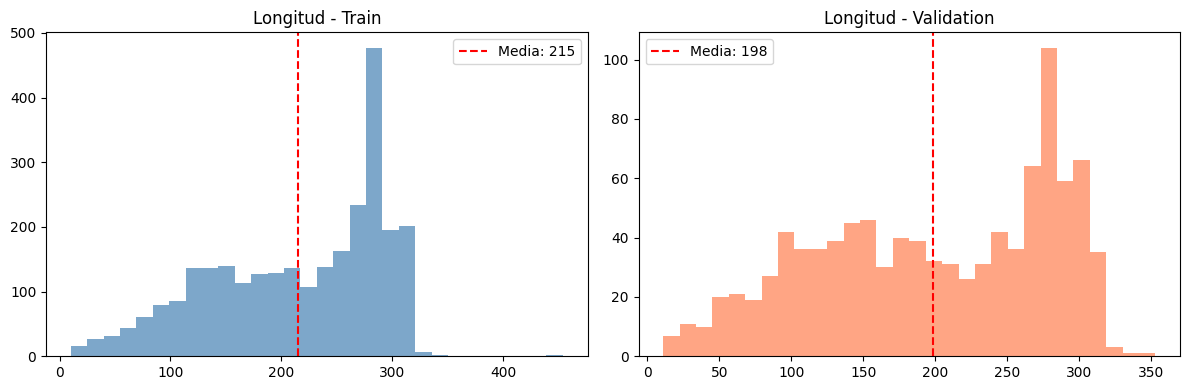

Media train: 215 chars
Media val: 198 chars


In [35]:
# Vemos cómo se distribuyen las longitudes de los tweets
dataset_train_df['text_length'] = dataset_train_df['text'].apply(len)
dataset_val_df['text_length'] = dataset_val_df['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dataset_train_df['text_length'], bins=30, color='steelblue', alpha=0.7)
axes[0].set_title('Longitud - Train')
axes[0].axvline(dataset_train_df['text_length'].mean(), color='red', linestyle='--',
               label=f"Media: {dataset_train_df['text_length'].mean():.0f}")
axes[0].legend()

axes[1].hist(dataset_val_df['text_length'], bins=30, color='coral', alpha=0.7)
axes[1].set_title('Longitud - Validation')
axes[1].axvline(dataset_val_df['text_length'].mean(), color='red', linestyle='--',
               label=f"Media: {dataset_val_df['text_length'].mean():.0f}")
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Media train: {dataset_train_df['text_length'].mean():.0f} chars")
print(f"Media val: {dataset_val_df['text_length'].mean():.0f} chars")


**Análisis de contenido de los tweets**

Para ello utiliza wordclouds

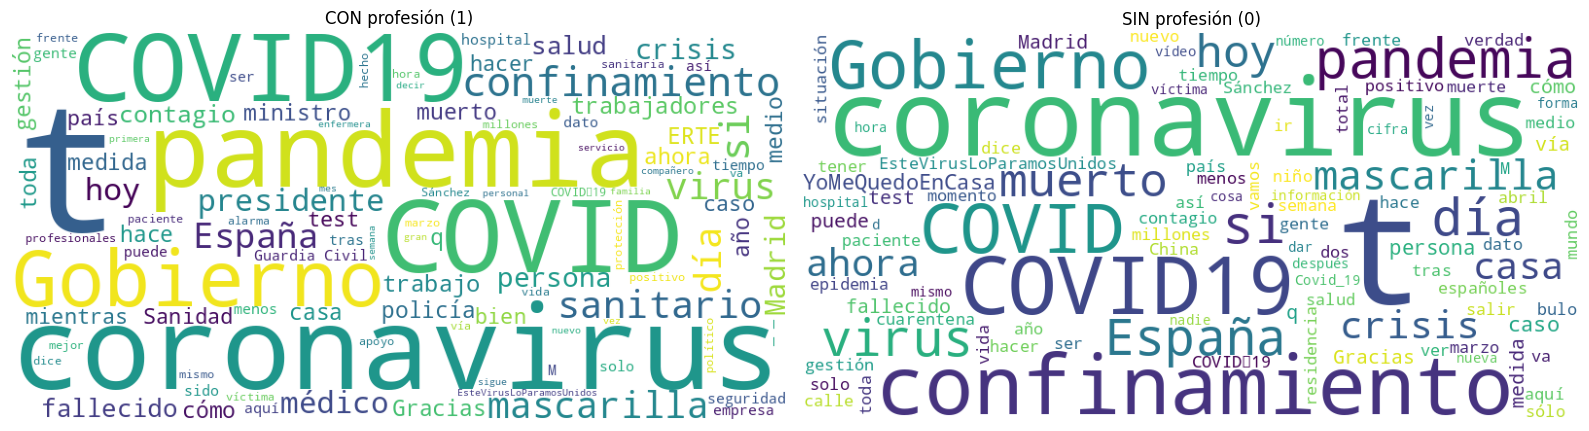

In [36]:
# Nubes de palabras para ver qué términos dominan en cada clase
stop_words = set(stopwords.words('spanish'))
stop_words.update(['https','http','co','rt','que','de','en','la','el',
                   'es','los','las','por','con','para','del','una','un',
                   'se','al','no','su','más','ya','lo','como','pero'])

texts_pos = ' '.join(dataset_train_df[dataset_train_df['label']==1]['text'].tolist())
texts_neg = ' '.join(dataset_train_df[dataset_train_df['label']==0]['text'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
wc1 = WordCloud(width=800, height=400, background_color='white',
                stopwords=stop_words, max_words=100).generate(texts_pos)
axes[0].imshow(wc1); axes[0].set_title('CON profesión (1)'); axes[0].axis('off')

wc2 = WordCloud(width=800, height=400, background_color='white',
                stopwords=stop_words, max_words=100).generate(texts_neg)
axes[1].imshow(wc2); axes[1].set_title('SIN profesión (0)'); axes[1].axis('off')
plt.tight_layout(); plt.show()


## Tokenización

El texto del dataset no está preparado para ser introducido en un modelo Transformers. Lleva a cabo el proceso de tokenización.

In [37]:
# IMPORTS
# Aquí importamos transformers porque ya pasó la instalación de dependencias
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
import evaluate


Selecciona un modelo apropiado para la tarea:

> Recuerda que en la siguiente celda sólo debes asignar un valor a model_name. No añadas más información en la celda.

### Justificación del modelo

Elegimos **BETO** (`dccuchile/bert-base-spanish-wwm-cased`) porque:

- **Idioma**: Preentrenado en español, que es el idioma de los tweets.
- **Whole Word Masking**: Mejora la comprensión morfológica del español.
- **Tamaño**: 110M params, viable para GPU T4 de Colab.
- **Rendimiento**: Competitivo en benchmarks NLP en español.

Alternativas: `PlanTL-GOB-ES/roberta-base-bne` (RoBERTa español), `bert-base-multilingual-cased` (multilingüe, pero los monolingües suelen rendir mejor).


In [38]:
#NO-MODIFY: VARIABLE NAME
model_name = 'dccuchile/bert-base-spanish-wwm-cased'


Puedes continuar con el proceso aquí:

In [39]:
# Cargamos el tokenizer del modelo que elegimos
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenizamos: padding a 128 tokens (suficiente para tweets)
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

In [40]:
# Preparamos el formato que necesita el Trainer
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')
tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

train_dataset = tokenized_datasets['train']
val_dataset = tokenized_datasets['validation']
test_dataset = tokenized_datasets['test']


## Fine-tuning

Carga el model para ser ajustado posteriormente:

In [41]:
# Cargamos BETO con cabeza de clasificación binaria
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2
)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

### Configuracion training_args

Configura los parámetros de entrenamiento del modelo.


>

> Recuerda que en la siguiente celda sólo debes asignar atributos a la variable training_args. No añadas  otras variables en la celda

In [42]:
#NO-MODIFY: VARIABLE NAME
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    seed=42,
    report_to='none',
)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Métricas de evaluación

Define las métricas de evaluación

In [43]:
# Métricas: accuracy y F1 (el F1 es el que evalúa el profesor)
accuracy_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')
precision_metric = evaluate.load('precision')
recall_metric = evaluate.load('recall')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_metric.compute(predictions=predictions, references=labels)['accuracy'],
        'f1': f1_metric.compute(predictions=predictions, references=labels)['f1'],
        'precision': precision_metric.compute(predictions=predictions, references=labels)['precision'],
        'recall': recall_metric.compute(predictions=predictions, references=labels)['recall'],
    }


### Ajuste del modelo

Lleva a cabo el ajuste del modelo:

In [44]:


# Fix para bug de torchvision en Colab
import datasets as _ds_config
_ds_config.config.TORCHVISION_AVAILABLE = False

# Creamos el Trainer y lanzamos el entrenamiento
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)
trainer.train()



Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.370571,0.284564,0.908909,0.831169,0.744186,0.941176
2,0.179950,0.218065,0.934935,0.873294,0.814545,0.941176
3,0.102703,0.272986,0.935936,0.876448,0.810714,0.953782


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=525, training_loss=0.27460645062582834, metrics={'train_runtime': 263.9948, 'train_samples_per_second': 31.66, 'train_steps_per_second': 1.989, 'total_flos': 549770550174720.0, 'train_loss': 0.27460645062582834, 'epoch': 3.0})

## Evaluacion

Una vez llevada a cabo el entrenamiento, realiza la evaluación del modelo.

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.102703,0.272986,3,0.935936,0.876448,0.810714,0.953782


Resultados:
  eval_loss: 0.2730
  eval_accuracy: 0.9359
  eval_f1: 0.8764
  eval_precision: 0.8107
  eval_recall: 0.9538



=== Classification Report ===
               precision    recall  f1-score   support

Sin profesión       0.98      0.93      0.96       761
Con profesión       0.81      0.95      0.88       238

     accuracy                           0.94       999
    macro avg       0.90      0.94      0.92       999
 weighted avg       0.94      0.94      0.94       999



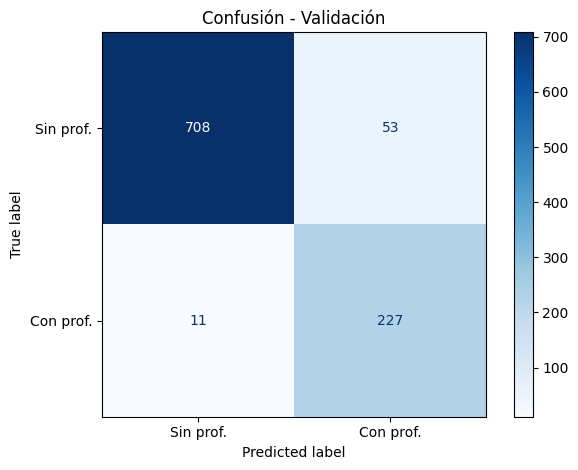

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluación general
eval_results = trainer.evaluate()
print("Resultados:")
for k, v in eval_results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# Detalle por clase
preds = trainer.predict(val_dataset)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = preds.label_ids

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=['Sin profesión','Con profesión']))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Sin prof.','Con prof.']).plot(cmap='Blues')
plt.title('Confusión - Validación')
plt.tight_layout(); plt.show()


## Genera predicciones

Genera predicciones sobre el test set. Recuerda que el archivo que generes y adjuntes al ejercicio debe tener dos columnas:


| id         | label |
|------------|-------|
| 1234567890 | 1     |
| 1234567891 | 0     |
| 1234567892 | 0     |
| 1234567893 | 1     |

- El archivo debe estar en formato **TSV** (separado por tabuladores).
- Debe contener exactamente **dos columnas**: `id` y `label`.
- Es obligatorio incluir la **cabecera**.


In [46]:
# Hago la predicción directamente con el modelo porque el Trainer
# da error de CUDA con las labels del test (que valen -1)
import torch

model.eval()
predictions = []
test_texts = dataset_test_df['text'].tolist()
batch_size = 32

# Recorro los tweets del test en lotes de 32
for i in range(0, len(test_texts), batch_size):
    batch = test_texts[i:i+batch_size]
    inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors='pt')
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
    preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
    predictions.extend(preds)

# Usamos tweet_id como columna id en el archivo final
predictions_df = pd.DataFrame({'id': dataset_test_df['tweet_id'].values, 'label': predictions})
predictions_df.to_csv('MANRIQUE_LEZAMETA_STEPHANY_ejercicio1_predicciones.tsv', sep='\t', index=False)

print(f"Archivo guardado. Total: {len(predictions_df)} predicciones")
print(predictions_df['label'].value_counts())
predictions_df.head()


Archivo guardado. Total: 1001 predicciones
label
0    730
1    271
Name: count, dtype: int64


,id,label
0,1277969650051997701,1
1,1263161378627600385,0
2,1255919996779315208,0
3,1282361712117780486,0
4,1267872916009615364,0


### Prueba de otros modelos